# CHƯƠNG 10: PHÂN TÍCH PHƯƠNG SAI ĐA BIẾN (MANOVA) VÀ MỞ RỘNG

Trong các chương trước, chúng ta đã tập trung vào việc dự báo hoặc phân loại một biến phụ thuộc duy nhất ($Y$). Tuy nhiên, thế giới kinh doanh thường đòi hỏi chúng ta phải quan sát nhiều kết quả (outcomes) đồng thời. Ví dụ: Một chiến dịch khuyến mãi không chỉ tác động đến *Doanh số* mà còn tác động đến *Sự hài lòng* và *Lòng trung thành*. Nếu phân tích rời rạc từng biến, chúng ta sẽ bỏ lỡ bức tranh tổng thể về sự tương tác giữa các hệ thống. MANOVA chính là công cụ giải quyết bài toán này.

---

## 10.1. Nhắc lại ANOVA: Phân tích phương sai một chiều (One-way ANOVA)

Để hiểu MANOVA, trước hết chúng ta phải nắm vững nền tảng của ANOVA (Analysis of Variance). 

### 10.1.1. Khi nào sử dụng ANOVA?
ANOVA được sử dụng khi nhà nghiên cứu muốn so sánh giá trị trung bình của **một biến phụ thuộc liên tục** ($Y$) trên **nhiều nhóm độc lập** được xác định bởi một biến phân loại ($X$). 

**Ví dụ trong Marketing:** Ngân hàng muốn kiểm tra xem liệu "Số dư tiền gửi trung bình" (biến $Y$ liên tục) có khác biệt đáng kể giữa 3 nhóm khách hàng: "Bình dân", "Thân thiết", và "VIP" (biến $X$ có 3 nhóm) hay không.

### 10.1.2. Triết lý của ANOVA: Phân tách phương sai
ANOVA không trực tiếp so sánh các giá trị trung bình. Thay vào đó, nó phân tách tổng biến thiên (Total Variance) của dữ liệu thành hai nguồn chính:
1. **Biến thiên giữa các nhóm (Between-group Variance - $SSB$):** Sự khác biệt do tác động của việc phân nhóm gây ra.
2. **Biến thiên trong nội bộ nhóm (Within-group Variance - $SSW$):** Sự khác biệt ngẫu nhiên giữa các cá thể trong cùng một nhóm (sai số).

**Toán học của ANOVA:**
Gọi $y_{ij}$ là quan sát thứ $i$ trong nhóm $j$. Tổng bình phương độ lệch ($SST$) được tính:

$$SST = \sum_{j=1}^{k} \sum_{i=1}^{n_j} (y_{ij} - \bar{y}_{..})^2 = SSB + SSW$$

**Giải thích ký hiệu:**
- $k$: Số lượng nhóm.
- $n_j$: Số lượng quan sát trong nhóm $j$.
- $\bar{y}_{..}$: Giá trị trung bình tổng thể của tất cả các quan sát.
- $SSB = \sum_{j=1}^{k} n_j (\bar{y}_{.j} - \bar{y}_{..})^2$: Đo lường khoảng cách giữa các tâm nhóm.
- $SSW = \sum_{j=1}^{k} \sum_{i=1}^{n_j} (y_{ij} - \bar{y}_{.j})^2$: Đo lường độ phân tán bên trong từng nhóm.

**Kiểm định F (F-statistic):**
$$F = \frac{SSB / (k-1)}{SSW / (N-k)}$$
Nếu tỷ số $F$ đủ lớn ($p$-value < 0.05), ta bác bỏ giả thuyết $H_0$ và kết luận rằng ít nhất có hai nhóm có giá trị trung bình khác nhau.

---

## 10.2. MANOVA (Multivariate Analysis of Variance)

Khi chúng ta có từ **hai biến phụ thuộc liên tục trở lên** (ví dụ $Y_1$: Doanh thu, $Y_2$: Chi phí Marketing), MANOVA trở thành lựa chọn bắt buộc.

### 10.2.1. Tại sao không chạy nhiều mô hình ANOVA riêng lẻ?

Việc thực hiện $p$ lần kiểm định ANOVA cho $p$ biến phụ thuộc dẫn đến hai sai lầm nghiêm trọng:

1.  **Sự gia tăng sai lầm loại I (Inflation of Type I Error):** 
    Nếu mỗi ANOVA có mức ý nghĩa $\alpha = 0.05$ (xác suất kết luận sai là 5%), thì khi chạy đồng thời 5 ANOVA, xác suất mắc ít nhất một sai lầm loại I sẽ vọt lên mức: 
    $$1 - (1 - 0.05)^5 \approx 22.6\%$$
    Điều này làm mất đi tính nghiêm mật của nghiên cứu khoa học.
2.  **Bỏ qua sự tương quan giữa các biến phụ thuộc:** 
    Các biến phụ thuộc thường có mối liên hệ mật thiết với nhau. ANOVA chỉ nhìn vào các biến số như các đường thẳng song song. MANOVA nhìn vào dữ liệu dưới dạng các **Vector** trong không gian $p$-chiều, cho phép phát hiện sự khác biệt mà ANOVA đơn lẻ có thể bỏ sót do tác động cộng hưởng.

### 10.2.2. Các giả định bắt buộc của MANOVA

MANOVA cực kỳ nhạy cảm với dữ liệu. Trước khi đọc kết quả, ta phải thỏa mãn:
1.  **Phân phối chuẩn đa biến (Multivariate Normality):** Các biến phụ thuộc phải cùng nhau tuân theo phân phối chuẩn trong mỗi nhóm.
2.  **Tính đồng nhất của các ma trận hiệp phương sai (Homogeneity of Covariance Matrices):** 
    Các nhóm không chỉ phải có phương sai giống nhau mà cấu trúc tương quan giữa các biến cũng phải tương đồng. 
    - Kiểm định sử dụng: **Box's M Test**. 
    - *Lưu ý:* Nếu $p$-value của Box's M < 0.001, giả định bị vi phạm. Khi đó ta phải chuyển sang dùng thống kê Pillai's Trace vì nó bền bỉ (robust) hơn.
3.  **Tính độc lập (Independence):** Các quan sát phải độc lập với nhau.

---

### 10.2.3. Toán học của MANOVA: Từ Tổng bình phương đến Ma trận Phân tán

Trong MANOVA, chúng ta không còn các con số $SSB, SSW$ đơn lẻ mà chuyển sang các **Ma trận Phân tán (Scatter Matrices)** kích thước $p \times p$.

$$\mathbf{T} = \mathbf{B} + \mathbf{W}$$

**Giải thích chi tiết các thực thể ma trận:**
- $\mathbf{W}$ (Within-group SSCP matrix): Ma trận tổng bình phương và tích chéo trong nội bộ nhóm. Nó đại diện cho sai số và sự biến thiên không giải thích được.
- $\mathbf{B}$ (Between-group SSCP matrix): Ma trận tổng bình phương và tích chéo giữa các nhóm. Nó đại diện cho sự khác biệt giữa các tâm cụm (Centroids) của các nhóm trong không gian đa chiều.
- $\mathbf{T}$ (Total SSCP matrix): Tổng biến thiên toàn bộ hệ thống.

### 10.2.4. Các Thống kê kiểm định đa biến

Thay vì một tỷ số F duy nhất, MANOVA cung cấp các chỉ số dựa trên định thức và trị riêng của các ma trận này:

**1. Wilks' Lambda ($\Lambda$):**
Đây là chỉ số phổ biến nhất, đại diện cho tỷ lệ biến thiên **không được giải thích** bởi mô hình.

$$\Lambda = \frac{|\mathbf{W}|}{|\mathbf{B} + \mathbf{W}|} = \prod_{i=1}^{s} \frac{1}{1 + \lambda_i}$$

**Giải thích ý nghĩa:**
- $|\mathbf{W}|$: Định thức của ma trận sai số (thể tích của khối sai số).
- $|\mathbf{B} + \mathbf{W}|$: Định thức của ma trận tổng biến thiên.
- $\lambda_i$: Các trị riêng (eigenvalues) của ma trận $\mathbf{W}^{-1}\mathbf{B}$.
- **Giá trị $\Lambda$ càng nhỏ (tiến về 0)**, phần biến thiên giữa các nhóm càng lớn so với sai số, nghĩa là tác động của việc phân nhóm càng có ý nghĩa.

**2. Pillai's Trace:**
Được tính bằng tổng các tỷ lệ phương sai được giải thích dọc theo các trục thành phần.
$$V = \sum_{i=1}^{s} \frac{\lambda_i}{1 + \lambda_i}$$
Đây là chỉ số **an toàn nhất**. Khi các giả định về phương sai bị vi phạm hoặc kích thước mẫu nhỏ, Pillai's Trace cung cấp kết quả đáng tin cậy nhất.

**3. Hotelling's Trace:**
Tổng các tỷ số giữa biến thiên nhóm và biến thiên sai số.
$$H = \sum \lambda_i$$

---

---- KẾT QUẢ KIỂM ĐỊNH MANOVA ----
                    Multivariate linear model
                                                                  
------------------------------------------------------------------
         Intercept         Value  Num DF  Den DF   F Value  Pr > F
------------------------------------------------------------------
            Wilks' lambda  0.0108 2.0000 146.0000 6656.4912 0.0000
           Pillai's trace  0.9892 2.0000 146.0000 6656.4912 0.0000
   Hotelling-Lawley trace 91.1848 2.0000 146.0000 6656.4912 0.0000
      Roy's greatest root 91.1848 2.0000 146.0000 6656.4912 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
       Card_Tier         Value   Num DF  Den DF   F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda   0.0028 4.0000 292.0000

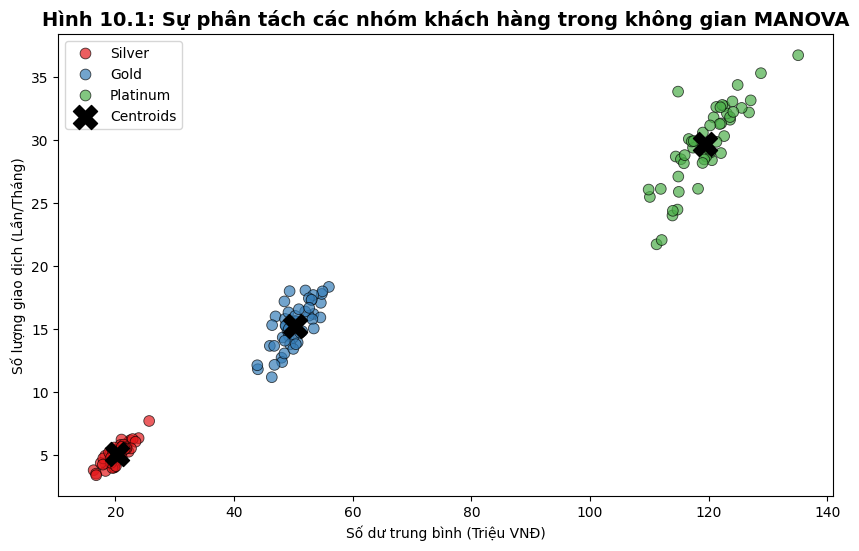

In [1]:
import numpy as np
import pandas as pd
from statsmodels.multivariate.manova import MANOVA
import seaborn as sns
import matplotlib.pyplot as plt

# ========================================================
# CASE STUDY: TÁC ĐỘNG CỦA HẠNG THẺ TÍN DỤNG ĐẾN HÀNH VI CHI TIÊU
# Biến độc lập (IV): Hạng thẻ (Silver, Gold, Platinum)
# Biến phụ thuộc (DVs): [Số dư trung bình (Balance), Số lượng giao dịch (Txn_Count)]
# ========================================================

np.random.seed(42)
n_per_group = 50

# 1. Sinh dữ liệu giả lập cho 3 nhóm
# Nhóm Silver: Balance ~ 20tr, Txn ~ 5 lần
silver = np.random.multivariate_normal([20, 5], [[5, 2], [2, 1]], n_per_group)
# Nhóm Gold: Balance ~ 50tr, Txn ~ 15 lần
gold = np.random.multivariate_normal([50, 15], [[10, 5], [5, 4]], n_per_group)
# Nhóm Platinum: Balance ~ 120tr, Txn ~ 30 lần
platinum = np.random.multivariate_normal([120, 30], [[20, 10], [10, 8]], n_per_group)

data = np.vstack([silver, gold, platinum])
groups = ['Silver']*n_per_group + ['Gold']*n_per_group + ['Platinum']*n_per_group

df = pd.DataFrame(data, columns=['Balance', 'Txn_Count'])
df['Card_Tier'] = groups

# ========================================================
# BƯỚC 1: THỰC HIỆN KIỂM ĐỊNH MANOVA
# ========================================================
# Công thức: 'BiếnY1 + BiếnY2 ~ BiếnX'
maov = MANOVA.from_formula('Balance + Txn_Count ~ Card_Tier', data=df)
print("---- KẾT QUẢ KIỂM ĐỊNH MANOVA ----")
print(maov.mv_test())

# ========================================================
# BƯỚC 2: TRỰC QUAN HÓA SỰ KHÁC BIỆT TRUNG BÌNH ĐA CHIỀU
# ========================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Balance', y='Txn_Count', hue='Card_Tier', 
                palette='Set1', s=60, alpha=0.7, edgecolor='k')

# Vẽ các Centroids (Tâm của các nhóm)
centroids = df.groupby('Card_Tier')[['Balance', 'Txn_Count']].mean()
plt.scatter(centroids['Balance'], centroids['Txn_Count'], 
            marker='X', s=300, c='black', label='Centroids')

plt.title('Hình 10.1: Sự phân tách các nhóm khách hàng trong không gian MANOVA', fontsize=14, fontweight='bold')
plt.xlabel('Số dư trung bình (Triệu VNĐ)')
plt.ylabel('Số lượng giao dịch (Lần/Tháng)')
plt.legend()
plt.show()

### Phân tích diễn giải Output MANOVA:

1.  **Wilks' Lambda:** Bạn sẽ thấy giá trị này trong bảng output của `statsmodels`. Với dữ liệu giả lập trên, Wilks' Lambda thường sẽ rất nhỏ (gần bằng 0) và giá trị $F$ tương ứng có $p < 0.001$. Điều này có nghĩa là Hạng thẻ tín dụng có tác động cực kỳ mạnh mẽ đến **tổng hợp hành vi** (Số dư và Tần suất giao dịch) của khách hàng.
2.  **Pillai's Trace:** Giá trị này tiến gần đến $s$ (số lượng biến phụ thuộc). Nó xác nhận tính ổn định của kết luận.
3.  **Phân tích Hình 10.1:** 
    - Hãy quan sát 3 dấu 'X' đen (Centroids). Trong MANOVA, chúng ta so sánh khoảng cách giữa các điểm này trong không gian 2 chiều. 
    - Các đám mây điểm Silver, Gold và Platinum tách biệt hoàn toàn. Nếu chúng ta chỉ dùng ANOVA cho `Balance`, ta thấy sự khác biệt. Nếu chỉ dùng ANOVA cho `Txn_Count`, ta cũng thấy sự khác biệt. Nhưng MANOVA cho thấy một cấu trúc tương quan dương: Khách hàng có số dư cao thì cũng có xu hướng giao dịch nhiều hơn. Đây là thông tin quan trọng mà các ANOVA đơn lẻ bỏ qua.

**Kết luận chiến lược:** Ngân hàng nên thiết kế các đặc quyền khác nhau cho từng phân khúc vì hành vi tài chính của họ là các thực thể khác biệt rõ rệt trong không gian đa biến.

# 10.3. Mở rộng: Khi dữ liệu có yếu tố thời gian (Time Series & Panel Data)

Trong các phần trước, chúng ta giả định rằng các quan sát là độc lập với nhau (Cross-sectional data). Tuy nhiên, trong kinh tế vĩ mô và tài chính, các biến số thường được theo dõi liên tục theo thời gian. Khi đó, giá trị của ngày hôm nay thường là "di sản" của ngày hôm qua, và các biến số khác nhau có thể tương tác với nhau theo những độ trễ nhất định. Mục này cung cấp cái nhìn tổng quan về cách xử lý các cấu trúc dữ liệu đa biến phức tạp này.

---

### 10.3.1. Khái niệm Tính dừng (Stationarity)

Trước khi thực hiện bất kỳ phân tích đa biến nào trên chuỗi thời gian, ta phải kiểm tra **Tính dừng**. Một chuỗi thời gian được gọi là dừng (yếu) nếu các đặc tính thống kê của nó không thay đổi theo thời gian.

**Điều kiện toán học:**
1. **Trung bình không đổi:** $E(y_t) = \mu$ với mọi $t$.
2. **Phương sai không đổi:** $Var(y_t) = \sigma^2$ với mọi $t$.
3. **Hiệp phương sai chỉ phụ thuộc vào độ trễ (lag):** $Cov(y_t, y_{t-k}) = \gamma_k$, không phụ thuộc vào thời điểm $t$.

> **Lưu ý:** Nếu chuỗi không dừng (ví dụ có xu hướng tăng - trend), các kiểm định thống kê sẽ dẫn đến hiện tượng **Hồi quy ảo (Spurious Regression)**, nơi hai biến hoàn toàn không liên quan vẫn cho kết quả tương quan rất cao chỉ vì chúng cùng tăng theo thời gian.

---

### 10.3.2. Mô hình Vector tự hồi quy (VAR - Vector Autoregression)

Trong MANOVA, chúng ta so sánh sự khác biệt giữa các nhóm. Trong **VAR**, chúng ta nghiên cứu sự tương tác động giữa các biến theo thời gian. Trong mô hình VAR, **mọi biến đều là biến nội sinh**. Mỗi biến là một hàm của các giá trị trễ của chính nó và giá trị trễ của tất cả các biến khác trong hệ thống.

**Trực giác (Ví dụ về Bộ ba vĩ mô):**
Xét hệ thống gồm: Lãi suất ($r$), Lạm phát ($\pi$), và Cung tiền ($m$).
- Lãi suất hôm nay bị ảnh hưởng bởi Lạm phát tháng trước.
- Lạm phát hôm nay bị ảnh hưởng bởi Cung tiền 6 tháng trước.
- Cung tiền lại được điều chỉnh dựa trên Lãi suất quá khứ.

**Phương trình dạng ma trận (VAR bậc 1):**
$$\mathbf{Y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{Y}_{t-1} + \boldsymbol{\epsilon}_t$$

Mô hình này cho phép chúng ta thực hiện **Phân tích Phản ứng xung (Impulse Response Function - IRF)**: Nếu Lãi suất đột ngột tăng 1%, thì Lạm phát sẽ dao động như thế nào trong 12 tháng tới?

---

### 10.3.3. Dữ liệu mảng (Panel Data): Fixed Effects vs. Random Effects

**Dữ liệu mảng** là sự kết hợp giữa dữ liệu chéo (nhiều đối tượng $i$) và chuỗi thời gian (nhiều thời điểm $t$). Ví dụ: Theo dõi 100 doanh nghiệp trong 10 năm.

Cấu trúc cơ bản: $y_{it} = \beta x_{it} + \alpha_i + \epsilon_{it}$

Trong đó $\alpha_i$ là **Hiệu ứng cá biệt**, đại diện cho những đặc điểm không quan sát được của đối tượng $i$ không thay đổi theo thời gian (ví dụ: văn hóa doanh nghiệp).

| Tiêu chí | Hiệu ứng cố định (Fixed Effects - FE) | Hiệu ứng ngẫu nhiên (Random Effects - RE) |
| :--- | :--- | :--- |
| **Bản chất $\alpha_i$** | Là các hằng số cần ước lượng cho từng đối tượng. | Là các biến ngẫu nhiên, một phần của sai số. |
| **Giả định** | Cho phép $\alpha_i$ tương quan với biến độc lập $x$. | Bắt buộc $\alpha_i$ KHÔNG tương quan với $x$. |
| **Ưu điểm** | Loại bỏ nội sinh do các biến ẩn không đổi. | Hiệu quả hơn nếu giả định không tương quan thỏa mãn. |

**Kiểm định Hausman:** Thường được dùng để quyết định chọn FE hay RE. Nếu $p < 0.05$, chúng ta chọn Fixed Effects.

---- KIỂM ĐỊNH TÍNH DỪNG ----
ADF Statistic (Inflation): -5.8139
p-value: 0.0000
ADF Statistic (Interest_Rate): -4.5868
p-value: 0.0001


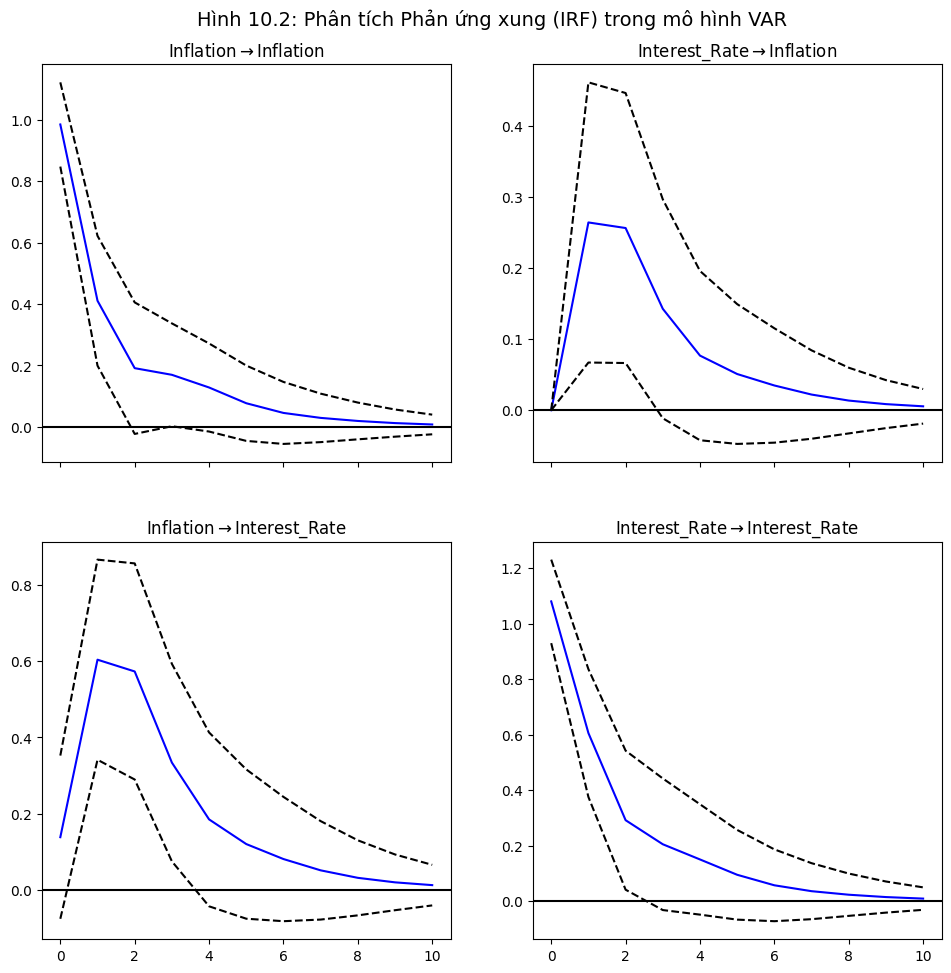

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# ========================================================
# GIẢ LẬP CHUỖI THỜI GIAN ĐA BIẾN (Lạm phát & Lãi suất)
# ========================================================
np.random.seed(123)
nobs = 100

# Sinh dữ liệu có tính tương tác
def generate_var_data():
    inf = [0]
    ir = [0]
    for _ in range(nobs):
        new_inf = 0.5 * inf[-1] + 0.2 * ir[-1] + np.random.normal()
        new_ir = 0.3 * inf[-1] + 0.6 * ir[-1] + np.random.normal()
        inf.append(new_inf)
        ir.append(new_ir)
    return pd.DataFrame({'Inflation': inf, 'Interest_Rate': ir})

df_ts = generate_var_data()

# 1. Kiểm định tính dừng (ADF Test)
def check_stationarity(series, name):
    result = adfuller(series)
    print(f'ADF Statistic ({name}): {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

print("---- KIỂM ĐỊNH TÍNH DỪNG ----")
check_stationarity(df_ts['Inflation'], 'Inflation')
check_stationarity(df_ts['Interest_Rate'], 'Interest_Rate')

# 2. Huấn luyện mô hình VAR
model = VAR(df_ts)
results = model.fit(maxlags=2)

# 3. Vẽ Phản ứng xung (Impulse Response Function)
irf = results.irf(10)
irf.plot(orth=True)
plt.suptitle('Hình 10.2: Phân tích Phản ứng xung (IRF) trong mô hình VAR', fontsize=14)
plt.show()

# 10.4. THỰC HÀNH PYTHON: MANOVA TRONG NGHIÊN CỨU GIÁO DỤC

Trong thực tế giáo dục, một phương pháp giảng dạy mới không bao giờ chỉ tác động đến một khía cạnh duy nhất. Chúng ta kỳ vọng sự thay đổi đồng thời trên nhiều môn học liên quan. Ví dụ: Việc áp dụng học tập qua dự án (Project-based Learning) có thể cải thiện đồng thời cả điểm Toán, Lý và Hóa của học sinh.

Dưới đây là quy trình thực thi MANOVA để kiểm định tác động này.

---

In [3]:
import numpy as np
import pandas as pd
from statsmodels.multivariate.manova import MANOVA
import seaborn as sns
import matplotlib.pyplot as plt

# ========================================================
# BƯỚC 1: GIẢ LẬP DỮ LIỆU ĐIỂM SỐ GIÁO DỤC (N=150)
# Biến độc lập: Phương pháp giảng dạy (Traditional, Interactive, Online)
# Biến phụ thuộc: Điểm Toán (Math), Lý (Physics), Hóa (Chemistry)
# ========================================================

np.random.seed(42)
n = 50

# Nhóm 1: Truyền thống (Điểm trung bình vừa phải, tương quan thấp)
trad = np.random.multivariate_normal([6.5, 6.0, 6.2], [[0.5, 0.2, 0.1], [0.2, 0.5, 0.2], [0.1, 0.2, 0.5]], n)
# Nhóm 2: Tương tác (Điểm cao hơn, tương quan giữa các môn khoa học mạnh)
inter = np.random.multivariate_normal([8.0, 7.8, 7.5], [[0.6, 0.4, 0.3], [0.4, 0.6, 0.4], [0.3, 0.4, 0.6]], n)
# Nhóm 3: Trực tuyến (Điểm biến động rộng, tập trung vào môn lý thuyết)
online = np.random.multivariate_normal([7.0, 6.5, 6.8], [[1.0, 0.3, 0.2], [0.3, 1.0, 0.3], [0.2, 0.3, 1.0]], n)

data = np.vstack([trad, inter, online])
methods = ['Traditional']*n + ['Interactive']*n + ['Online']*n

df = pd.DataFrame(data, columns=['Math', 'Physics', 'Chemistry'])
df['Method'] = methods

# ========================================================
# BƯỚC 2: THỰC THI KIỂM ĐỊNH MANOVA
# ========================================================
maov = MANOVA.from_formula('Math + Physics + Chemistry ~ Method', data=df)
results = maov.mv_test()

print("---- KẾT QUẢ PHÂN TÍCH BIẾN METHOD ----")
print(results.results['Method']['stat'])


---- KẾT QUẢ PHÂN TÍCH BIẾN METHOD ----
                           Value Num DF     Den DF    F Value Pr > F
Wilks' lambda           0.478275      6      290.0  21.555524    0.0
Pillai's trace          0.542548    6.0      292.0  18.116534    0.0
Hotelling-Lawley trace  1.047311      6  191.56582  25.224257    0.0
Roy's greatest root     1.003945      3        146  48.858663    0.0


### Phân tích và Đọc kết quả MANOVA:

Trong bảng output của `statsmodels`, chúng ta cần tập trung vào hàng **Wilks' lambda**:

1. **Chỉ số Wilks' lambda:** Nếu giá trị này nhỏ (ví dụ < 0.2), điều đó cho thấy phần lớn biến thiên của tổ hợp điểm số (Toán, Lý, Hóa) được giải thích bởi sự khác biệt giữa các phương pháp giảng dạy.
2. **Giá trị p-value (Pr > F):** Nếu `Pr > F` nhỏ hơn mức ý nghĩa $\alpha = 0.05$, chúng ta bác bỏ giả thuyết $H_0$. 
   - **Kết luận:** Có bằng chứng thống kê cho thấy phương pháp giảng dạy có tác động đáng kể đến kết quả học tập chung của học sinh trên cả 3 môn học.
3. **Bước tiếp theo:** Nếu MANOVA có ý nghĩa, chúng ta mới tiến hành các bài kiểm định **Post-hoc ANOVA** cho từng môn đơn lẻ để xem cụ thể môn nào bị tác động mạnh nhất.

---

# 10.5. LỜI KẾT GIÁO TRÌNH: TỪ DỮ LIỆU ĐẾN QUYẾT ĐỊNH

Chúng ta đã đi qua một hành trình từ những mô hình Hồi quy đơn giản, các kỹ thuật giảm chiều PCA/EFA, đến các cấu trúc phức tạp như Phân cụm và MANOVA. 

### 10.5.1. Tư duy Đa biến
Thế giới không vận hành theo các đường thẳng đơn độc. Mọi hiện tượng kinh tế - xã hội đều là kết quả của sự tương tác đa chiều. Mục tiêu của giáo trình này không phải là dạy bạn cách chạy code, mà là trang bị cho bạn **lăng kính đa biến** để nhìn thấu các cấu trúc ẩn giấu trong dữ liệu, từ đó đưa ra các quyết định dựa trên bằng chứng (Evidence-based decisions).

### 10.5.2. Đạo đức trong Khoa học Dữ liệu (Ethics in Data Science)
Như nhà kinh tế học Ronald Coase đã từng nói: *"Nếu bạn tra tấn dữ liệu đủ lâu, nó sẽ tự khai ra bất cứ điều gì bạn muốn"* (Data Torturing).

Trong kỷ nguyên AI và Big Data, ranh giới giữa việc khám phá tri thức và việc bóp méo dữ liệu trở nên rất mong manh. Hãy lưu ý tránh các sai lầm đạo đức sau:
1. **P-hacking:** Cố tình thử nghiệm hàng trăm mô hình khác nhau chỉ để tìm ra một kết quả có $p < 0.05$ mang tính ngẫu nhiên.
2. **Cherry-picking:** Chỉ báo cáo những kết quả ủng hộ giả thuyết của bạn và lờ đi những bằng chứng ngược lại.
3. **Bỏ qua giả định:** Ép dữ liệu vào mô hình (như MANOVA) khi các giả định cốt lõi bị vi phạm nghiêm trọng.

**Lời nhắn nhủ cuối cùng:** Một mô hình tốt là một mô hình trung thực. Hãy dùng dữ liệu để kể câu chuyện thật của doanh nghiệp và nền kinh tế, đừng dùng nó để trang trí cho những giả định sai lầm. Chúc các bạn thành công trên con đường trở thành những nhà phân tích dữ liệu tử tế và thông tuệ!